# Exploratory Data Analysis for Text and Vote Label
This notebook performs EDA on the `fetched_data.json` dataset, focusing on text and vote label analysis. Tasks include:
- Data overview and label distribution
- Text length analysis
- Word frequency and word cloud per label
- Keyword and URL analysis
- Sentiment analysis (optional, if supported)

In [1]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

from nltk.corpus import stopwords
import nltk

In [6]:
# Load the JSON data
with open('d:/laragon/www/Skripsi/Preprocessing/fetched_data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
if isinstance(data, dict):
    for v in data.values():
        if isinstance(v, list):
            data = v
            break
df = pd.DataFrame(data)
print('Number of records:', len(df))
print(df.head(10))

Number of records: 11825
                                                text  votes
0  Harinya sudah datang, mari meramaikan hari ini...  False
1  mantap linkBONBON777 berani kasi kemenangan be...   True
2  WD lagi coy di MAHASLOT royal bro 20jt dikasih...   True
3                    Gacor parah ey mantap #MAHASLOT   True
4  🤑Udah Siap Buat Klaim 𝗙𝗥𝗘𝗘𝗕𝗘𝗧 𝗣𝗘𝗣𝗘𝟴𝟴𝟵 ?\n\nCar...   True
5  𝐒𝐇𝐈𝐎𝐊𝐀𝐌𝐁𝐈𝐍𝐆𝟓  Link paling ajaib kasih scatter ...   True
6  Ku kira isi nya ga sesuai ekspetasi ternyata,,...   True
7  🔥 SPECIAL NEW PROVIDER GAME PANASNYA GGSOFT #P...   True
8  Info aja lur selagi masih bagus'nya baru dikas...   True
9  💱List apk Slot WD Tampa DP\n❓Depo 50k +20k Bon...   True


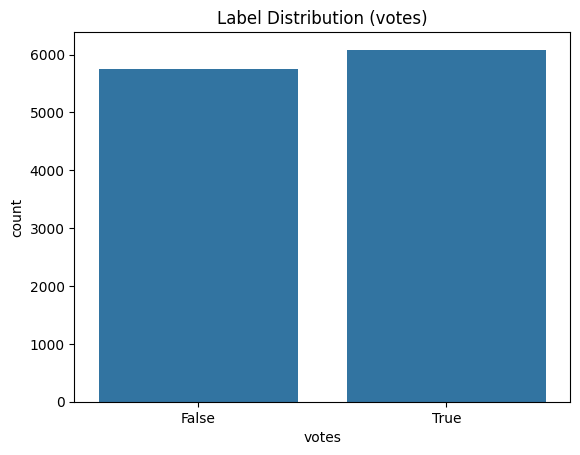

votes
True     6083
False    5742
Name: count, dtype: int64

In [ ]:
# Label distribution
sns.countplot(x='votes', data=df, y=)
plt.title('Label Distribution (votes)')
plt.show()
df['votes'].value_counts()

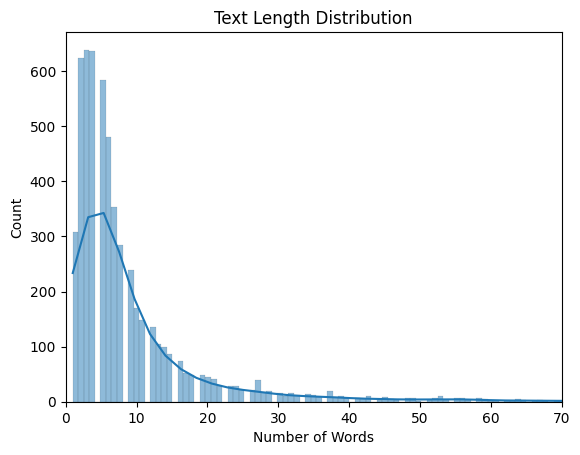

,count,mean,std,min,25%,50%,75%,max
votes,,,,,,,,
False,5742.0,10.034309,16.237633,1.0,3.0,6.0,10.0,435.0
True,6083.0,20.244287,16.889776,1.0,10.0,17.0,27.0,308.0


In [47]:
# Text length analysis
import numpy as np
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
# Only plot for label True
sns.histplot(df[df['votes'] == False]['text_length'], bins="auto", kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Number of Words')
plt.xlim(0, 70)
plt.xticks(np.arange(0, 71, 10))
plt.show()
df.groupby('votes')['text_length'].describe()

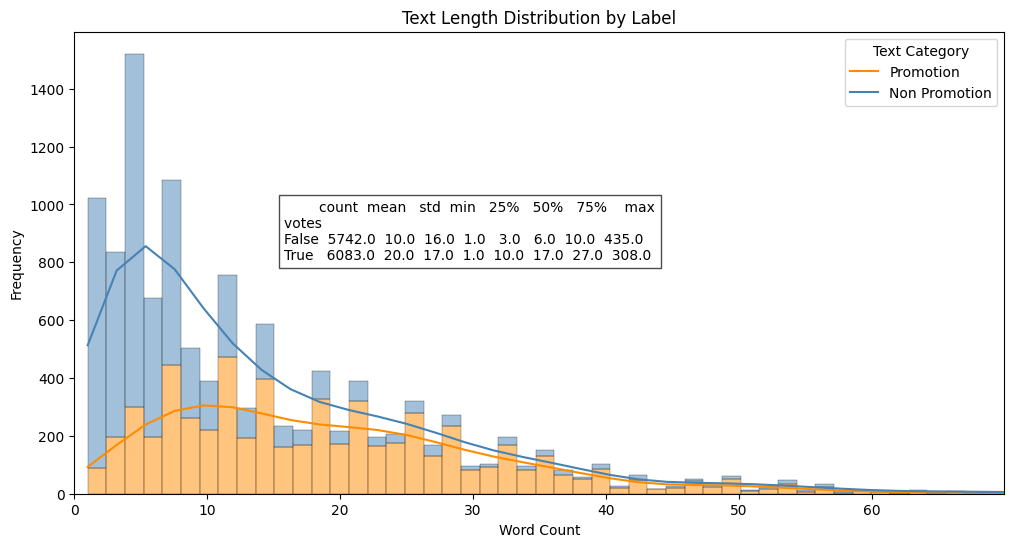

Statistik Deskriptif Panjang Teks per Label:
        count       mean        std  min   25%   50%   75%    max
votes                                                            
False  5742.0  10.034309  16.237633  1.0   3.0   6.0  10.0  435.0
True   6083.0  20.244287  16.889776  1.0  10.0  17.0  27.0  308.0


In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Asumsikan 'df' adalah DataFrame Anda dan memiliki kolom 'text' dan 'votes'.
# Jika kolom label Anda memiliki nama yang berbeda, silakan ganti 'votes'.

# 1. Menghitung panjang teks (jumlah kata)
# Bagian ini sudah benar dan tidak perlu diubah.
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['label_deskriptif'] = df['votes'].map({True: 'Promotion', False: 'Non Promotion'})
stats = df.groupby('votes')['text_length'].describe()

# Convert ke string yang rapi
stats_str = stats.round(0).to_string()

# 2. Visualisasi distribusi panjang teks untuk setiap label
plt.figure(figsize=(12, 6))
# Menggunakan parameter 'hue' untuk memisahkan plot berdasarkan kolom 'votes'
sns.histplot(data=df, x='text_length', hue='label_deskriptif', multiple="stack", kde=True, bins="auto"
             ,palette={'Non Promotion': 'steelblue', 'Promotion': 'darkorange'})
plt.title('Text Length Distribution by Label')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, 70)
plt.xticks(np.arange(0, 70, 10))
plt.legend(title='Text Category', labels=['Promotion', 'Non Promotion'])
plt.gcf().text(0.3, 0.5, stats_str, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# 3. Menampilkan statistik deskriptif untuk panjang teks per label
# Bagian ini sudah benar dan sangat berguna untuk analisis.
print("Statistik Deskriptif Panjang Teks per Label:")
print(df.groupby('votes')['text_length'].describe())



In [10]:
stopwords_custom = [
#   // Kata Ganti
    "aku", "saya", "kamu", "dia", "mereka", "kita", "kami", "engkau", "kalian",

#   // Kata Sambung
    "dan", "atau", "tetapi", "namun", "lalu", "kemudian", "sehingga", "karena", "jika", "meskipun", "agar", "supaya",

#   // Kata Depan / Preposisi
    "di", "ke", "dari", "pada", "untuk", "dengan", "tanpa", "terhadap", "dalam", "antara", "oleh",

#   // Partikel
    "lah", "kah", "pun", "nya",

#   // Kata Waktu Umum
    "sudah", "belum", "akan", "sedang", "telah", "baru", "masih",

#   // Kata Penunjuk
    "ini", "itu", "tersebut", "sini", "situ", "sana",

#   // Kata Tanya
    "apa", "siapa", "mengapa", "bagaimana", "kapan", "dimana",

#   // Lain-lain
    "setiap", "semua", "beberapa", "banyak", "sedikit", "seluruh",
    'yang', 'dan', 'di', 'ke', 'untuk', 'dengan', 'atau', 'ini', 'itu', 'nya', 'aja', 'situ', 'yg', 'langsung', 'coba', 'juga',
    'nih', 'kasih', 'ni', 'gw', 'ada', 'gak', 'ga', 'gua', 'gk','udah', 'bisa', 'lagi', 'sama', 'kalo'
]
stopwords_set = set(stopwords.words('indonesian')).union(set(stopwords_custom))


Top words for votes=True:


,Word,Frequency
0,main,1728
1,putrispin,1162
2,banget,1014
3,situs,890
4,s1tus,733
5,wd,682
6,link,634
7,gacor,557
8,menang,545
9,mantap,499


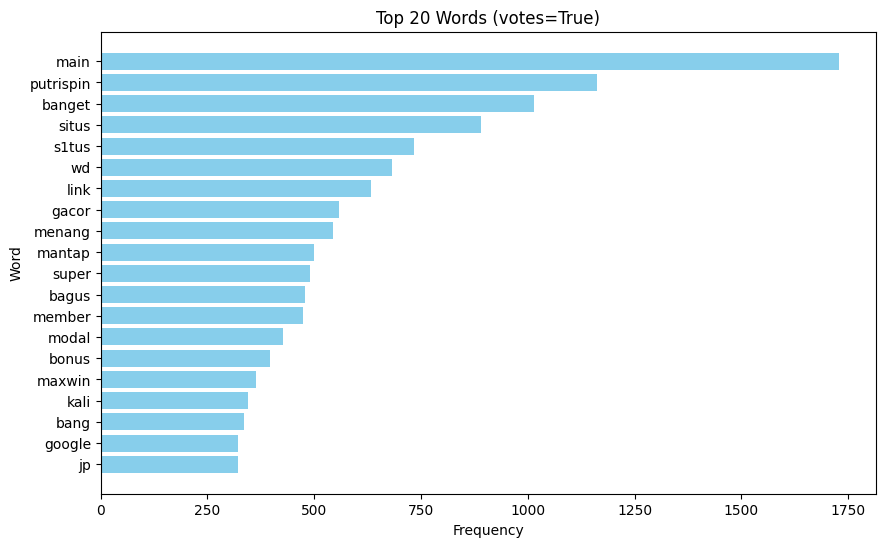

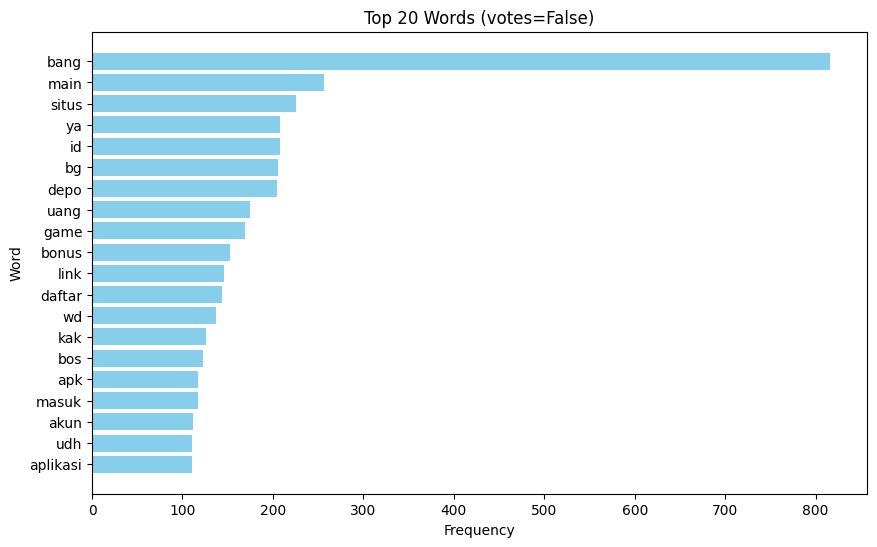

In [17]:
# Word frequency analysis for each label (table format, remove stopwords and punctuation)
from collections import Counter
from wordcloud import STOPWORDS
import pandas as pd
import string
from unidecode import unidecode
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(stopwords_set)
stop_words = set(stopwords.words('indonesian'))
custom_stopwords = stop_words.union(set(custom_stopwords))
def normalize_text(text):
    # Convert to ASCII, remove unsupported formatting
    return unidecode(str(text))
def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
    "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
def preprocess_text(text):
    # Remove emoji, lowercase, remove punctuation, split, remove duplicates, join back
    text = remove_emoji(str(text))
    words = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    unique_words = list(dict.fromkeys(words))
    return ' '.join(unique_words)

def get_top_words_table(texts, n=50):
    # Remove punctuation and lowercase
    def clean_text(text):
        # text = remove_emoji(text)
        text = normalize_text(text)
        text = preprocess_text(text)
        return str(text).lower().translate(str.maketrans('', '', string.punctuation))
    cleaned_texts = [clean_text(t) for t in texts]
    words = ' '.join(cleaned_texts).split()
    words = [w for w in words if w not in custom_stopwords]
    counter = Counter(words)
    df_freq = pd.DataFrame(counter.items(), columns=['Word', 'Frequency'])
    df_freq = df_freq.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
    return df_freq.head(n)
print('Top words for votes=True:')
display(get_top_words_table(df[df['votes']==True]['text'], n=20))
# print('Top words for votes=False:')
# display(get_top_words_table(df[df['votes']==False]['text']))
def plot_top_words(df_freq, title):
    plt.figure(figsize=(10,6))
    plt.barh(df_freq['Word'], df_freq['Frequency'], color='skyblue')
    plt.gca().invert_yaxis()  # highest at top
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

# Top words for votes=True
df_true = get_top_words_table(df[df['votes']==True]['text'], n=20)
plot_top_words(df_true, "Top 20 Words (votes=True)")

# Top words for votes=False
df_false = get_top_words_table(df[df['votes']==False]['text'], n=20)
plot_top_words(df_false, "Top 20 Words (votes=False)")

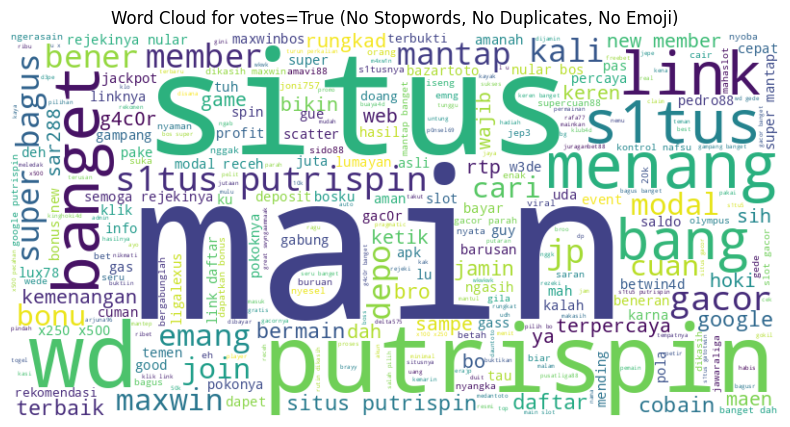

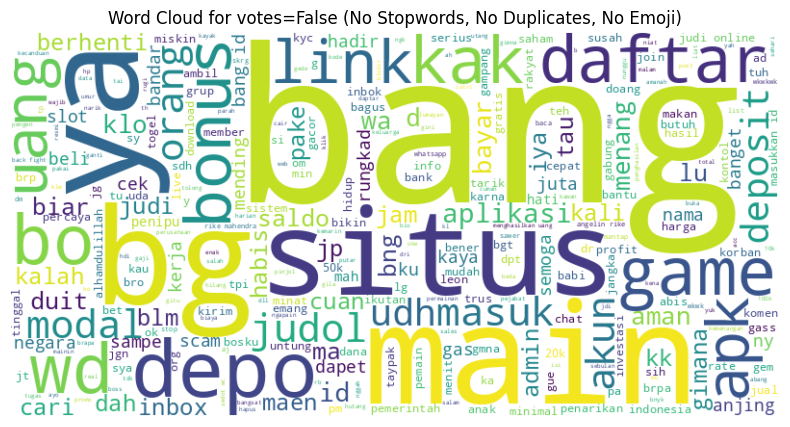

In [20]:
# Word cloud for each label (excluding stopwords, removing duplicates, and removing emoji/emote)
from wordcloud import STOPWORDS
custom_stopwords = set(STOPWORDS)
# Optionally add more stopwords relevant to your context
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(stopwords_set)
stop_words = set(stopwords.words('indonesian'))
custom_stopwords = stop_words.union(set(custom_stopwords))
import string
import re

from unidecode import unidecode

def normalize_text(text):
    # Convert to ASCII, remove unsupported formatting
    return unidecode(str(text))
def remove_emoji(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642"
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
    "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)
def preprocess_text(text):
    # Remove emoji, lowercase, remove punctuation, split, remove duplicates, join back
    text = remove_emoji(str(text))
    words = text.lower().translate(str.maketrans('', '', string.punctuation)).split()
    unique_words = list(dict.fromkeys(words))
    return ' '.join(unique_words)
for label in [True, False]:
    texts = df[df['votes']==label]['text'].dropna().astype(str).apply(normalize_text).apply(preprocess_text)
    all_text = ' '.join(texts)
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=custom_stopwords, max_words=300).generate(all_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for votes={label} (No Stopwords, No Duplicates, No Emoji)')
    plt.show()

Texts containing 'bonus': 569
Texts containing 'petir': 111
Texts containing 'link': 968
Texts containing 'daftar': 438
Texts containing URLs: 1268


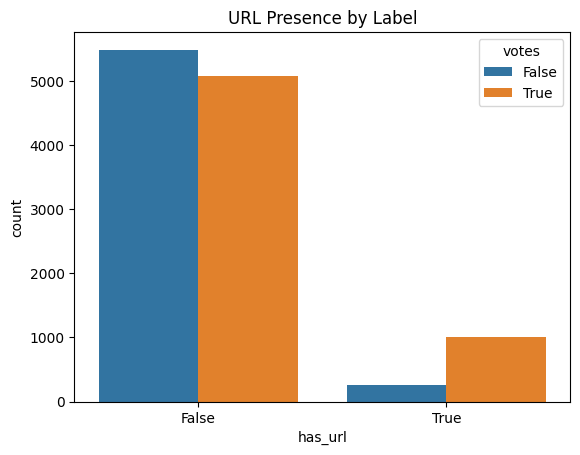

In [10]:
# Keyword and URL analysis
keywords = ['bonus', 'petir', 'link', 'daftar']
for kw in keywords:
    df[f'has_{kw}'] = df['text'].str.contains(kw, case=False, na=False)
    print(f"Texts containing '{kw}':", df[f'has_{kw}'].sum())
# URL presence
df['has_url'] = df['text'].str.contains(r'http[s]?://', na=False)
print('Texts containing URLs:', df['has_url'].sum())
sns.countplot(x='has_url', hue='votes', data=df)
plt.title('URL Presence by Label')
plt.show()

In [ ]:
# (Optional) Sentiment analysis if you have a sentiment library installed
# Example using textblob (pip install textblob)
try:
    from textblob import TextBlob
    df['sentiment'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
    sns.histplot(df['sentiment'], bins=30, kde=True)
    plt.title('Sentiment Distribution')
    plt.show()
    print(df.groupby('votes')['sentiment'].describe())
except ImportError:
    print('TextBlob not installed. Sentiment analysis skipped.')

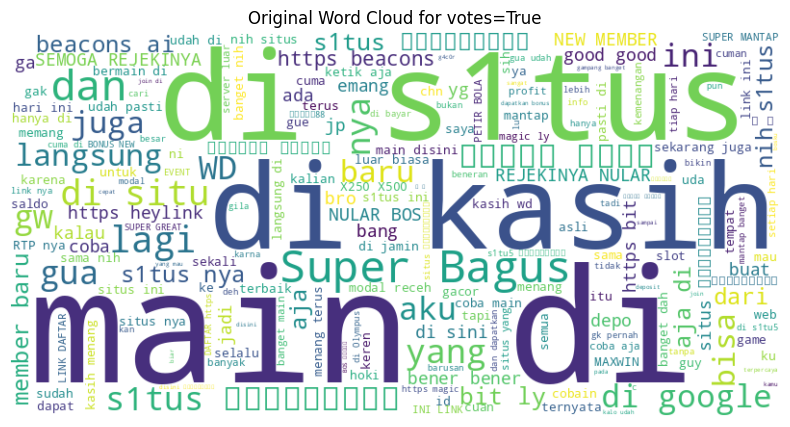

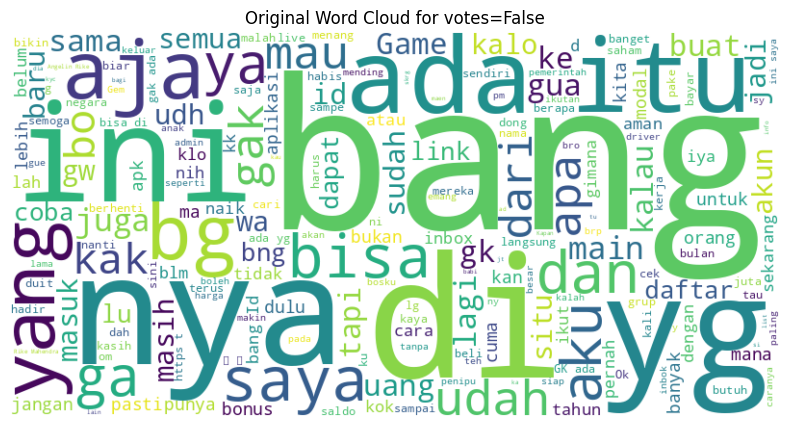

In [13]:
# Original word cloud for each label (no stopwords, no duplicate removal, no punctuation cleaning)
for label in [True, False]:
    texts = ' '.join(df[df['votes']==label]['text'].dropna().astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texts)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Original Word Cloud for votes={label}')
    plt.show()

In [38]:
# Paginated word frequency DataFrame display
import math
from IPython.display import display, clear_output
def show_paginated_df(df, page_size=20):
    total_pages = math.ceil(len(df) / page_size)
    page = 1
    while True:
        clear_output(wait=True)
        start = (page - 1) * page_size
        end = start + page_size
        print(f"Showing page {page}/{total_pages}")
        display(df.iloc[start:end])
        if page >= total_pages:
            break
        next_page = input('Press Enter for next page, or type q to quit: ')
        if next_page.lower() == 'q':
            break
        page += 1
# Example usage:
freq_df = get_top_words_table(df[df['votes']==True]['text'], n=300)
show_paginated_df(freq_df, page_size=20)

Showing page 15/15


,Word,Frequency
280,cair,58
281,togel,58
282,dikit,57
283,𝗗𝗘𝗟𝗧𝗔𝟱𝟳𝟱,57
284,kata,56
285,𝐆,56
286,permainan,56
287,pecahan,56
288,hasilnya,56
289,d3pe,56
